<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_3/blob/main/17_6_EXTRA_Implementing_GPT_from_Scrtach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementing GPT from scratch

This notebook provides a hands-on tutorial on building a simplified GPT-like language model from scratch using TensorFlow and Keras. The process begins with a small, custom dataset of short text samples, followed by tokenization and the creation of input-output pairs for training. Core components of the GPT architecture, such as the transformer block, scaled dot-product attention, and multi-head attention, are implemented step by step. Using these components, a decoder-only transformer model is constructed and trained on the dataset. Although the toy dataset is small and results in overfitting, this exercise is valuable for understanding the inner workings of GPT models, including how they process sequences and generate predictions. The notebook concludes by demonstrating text generation using the trained model.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, Dense, LayerNormalization, Dropout
from tensorflow.keras.models import Model
import tensorflow_datasets as tfds
import numpy as np

### Dataset:

In [ ]:
# Load the IMDB reviews dataset
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
train_dataset = dataset['train']

# Extract a small sample of the dataset
data = []
for example in train_dataset.take(50):
    review_text = example[0].numpy().decode('utf-8')
    data.append(review_text)


In [ ]:
print(len(data))
data[0]

50


"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."

In [ ]:
### To make the training process simpler, we'll create a small toy dataset
data = [
    'This was a horrible movie',
    'This is a nice one',
    'The acting was amazing',
    'The actors were good'
]

In [ ]:
# Tokenize the data
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(data)
vocab_size = len(tokenizer.word_index) + 1
sequences = tokenizer.texts_to_sequences(data)

# Create input-output pairs
input_sequences = []
output_words = []

for seq in sequences:
    for i in range(1, len(seq)):
        input_sequences.append(seq[:i])
        output_words.append(seq[i])

# Pad sequences
max_sequence_length = max(len(seq) for seq in input_sequences)
input_sequences = tf.keras.preprocessing.sequence.pad_sequences(input_sequences, maxlen=max_sequence_length, padding='post')
output_words = np.array(output_words)

print("Input Sequences:", input_sequences[0:3])
print("Output Words:", output_words[0:3])

Input Sequences: [[2 0 0 0]
 [2 1 0 0]
 [2 1 3 0]]
Output Words: [1 3 5]


In [ ]:
input_sequences.shape

(14, 4)

In [ ]:
input_sequences

array([[ 2,  0,  0,  0],
       [ 2,  1,  0,  0],
       [ 2,  1,  3,  0],
       [ 2,  1,  3,  5],
       [ 2,  0,  0,  0],
       [ 2,  1,  0,  0],
       [ 2,  1,  3,  0],
       [ 2,  1,  3,  7],
       [ 4,  0,  0,  0],
       [ 4,  9,  0,  0],
       [ 4,  9,  1,  0],
       [ 4,  0,  0,  0],
       [ 4, 11,  0,  0],
       [ 4, 11, 12,  0]], dtype=int32)

In [ ]:
output_words.shape

(14,)

In [ ]:
output_words

array([ 1,  3,  5,  6,  1,  3,  7,  8,  9,  1, 10, 11, 12, 13])

# Model

We'll create a GPT-like model in tensorflow using the decoder architecture from the paper [Attention is all you need](https://arxiv.org/pdf/1706.03762)

## Transformer Block

The key part of the transformer architecture is the transformer block composed mainly of the Scaled dot product module and the Multi-head attention module. Let's create those in tensorflow!

### Scaled dot product attention:

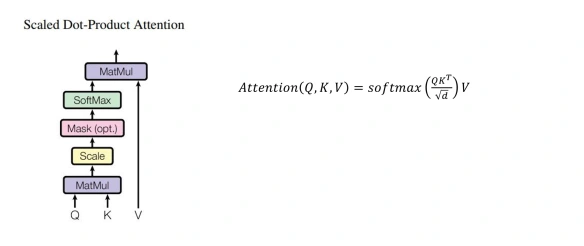

In [ ]:
class ScaledDotProductAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(ScaledDotProductAttention, self).__init__(**kwargs)

    def call(self, query, key, value, mask=None, causal=True):
        # The equation is:
        # attention(Q, K, V) = softmax(QK^T / sqrt(d_k))V

        # Q.K^T
        matmul_qk = tf.matmul(query, key, transpose_b=True)

        # Scale it
        # QK^T / sqrt(d_k)
        dk = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        # Add the mask to the scaled tensor if mask.
        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        if causal:
            # Create a causal mask by determining the size of the sequence
            seq_len = tf.shape(query)[-2]
            causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)

            # Apply the causal mask (set logits for future tokens to a very large negative number)
            scaled_attention_logits += (causal_mask - 1.0) * 1e9

        # softmax(QK^T / sqrt(d_k))
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)

        # attention(Q, K, V) = softmax(QK^T / sqrt(d_k))V
        output = tf.matmul(attention_weights, value)

        return output, attention_weights

### Multi-head attention

The following class will create the Multi-head Attention module. To do so we'll use the previous Scaled Dot-product attention

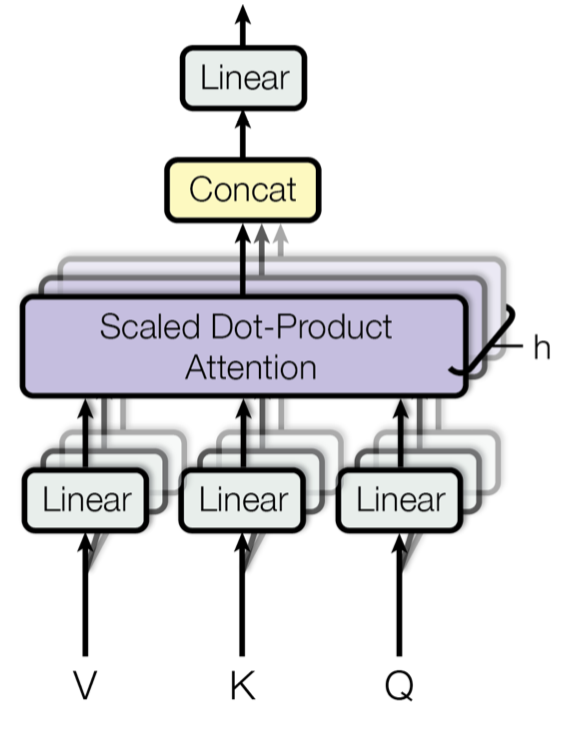


In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)

        # Number of heads
        self.num_heads = num_heads
        # Dimension of the linear projection of the embeddings
        self.d_model = d_model

        assert d_model % self.num_heads == 0

        # Dimension of the depth of each head
        self.depth = d_model // self.num_heads

        # Linear projections for Q, K, V
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)

        # Linear projection for the output
        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        # Initial shape (Batch, Sequence, Embedding)
        # Resulting dimension (Batch, Sequence, num_heads, depth)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        # Transpose to (Batch, num_heads, Sequence, depth)
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask):
        # Batch size
        batch_size = tf.shape(q)[0]

        # Generate the linear projection of Q, K, V
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        # Split the heads
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Apply the Scaled Dot Product Attention to the projected Q, K, and V heads
        scaled_attention, _ = ScaledDotProductAttention()(q, k, v, mask)

        # Transpose to (Batch, Sequence, num_heads, depth)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

        # Concatenate the heads
        # Resulting shape (Batch, Sequence, d_model)
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))

        # Apply the final linear projection
        output = self.dense(concat_attention)

        return output


### Transformer Block

Once we have the Multi-head Attention, we can actually create the transformer block that is the base od our transformer architecture


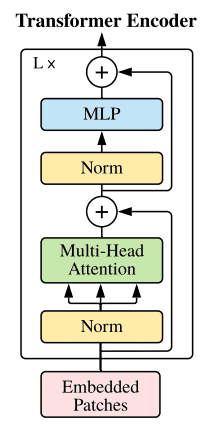

In [ ]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)

        # Multi-head Attention block with a projection embedding size d_model, and num_heads heads
        self.mha = MultiHeadAttention(d_model, num_heads)

        # MLP:
        # First dense layer with dff units and ReLU activation
        # Second dense layer with d_model units
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])

        # Normalization layers
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        # Dropout (optional)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training, mask):
        # Multi-head Attention
        attn_output = self.mha(x, x, x, mask)
        # Apply dropout
        attn_output = self.dropout1(attn_output, training=training)
        # Add the attention output to the input
        # X + Attention output
        out1 = self.layernorm1(x + attn_output)

        # Feed-forward network (MLP)
        ffn_output = self.ffn(out1)
        # Apply dropout
        ffn_output = self.dropout2(ffn_output, training=training)

        # Add the MLP output to the attention output
        # X + Attention output + MLP output
        out2 = self.layernorm2(out1 + ffn_output)

        return out2


### GPT Like model architecture

Finally, we'll create a GPT like model architecture. This architecture is basically a decoder transformer model

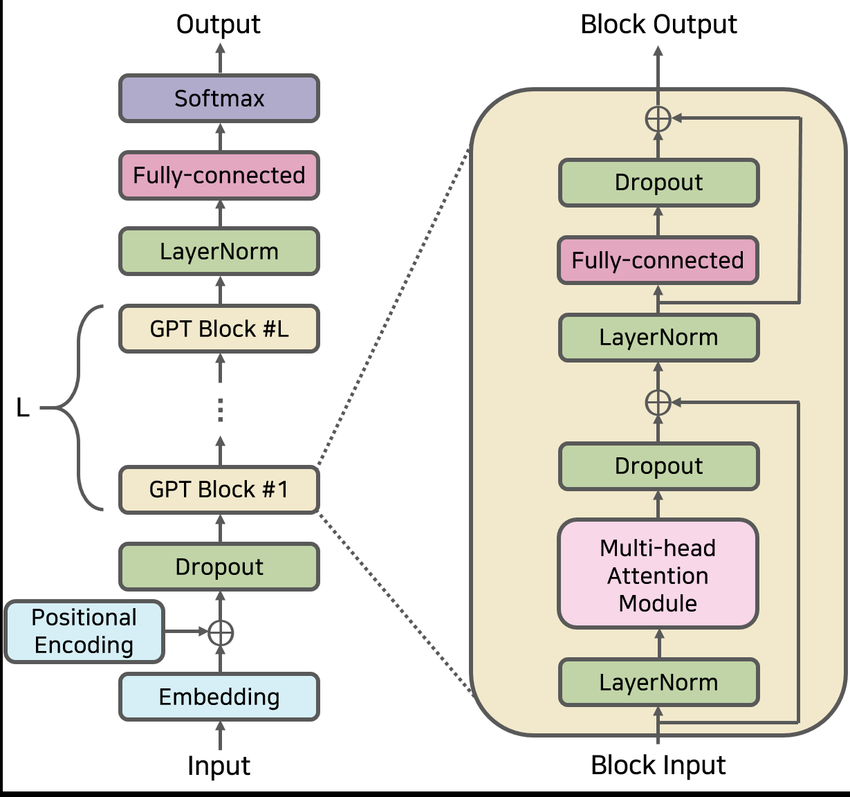

In [ ]:
class GPT(Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, rate=0.1):
        super(GPT, self).__init__()

        # Embedding layer to convert input tokens to vector embeddings
        self.embedding = Embedding(input_vocab_size, d_model)

        # Positional encoding layer to add positional information to the embeddings
        self.pos_encoding = self.positional_encoding(maximum_position_encoding, d_model)

        # Transformer blocks
        # Each transformer block consists of a multi-head attention layer and a point-wise feed-forward network
        # The output of each transformer block is fed into the next transformer block
        # This process is repeated num_layers times:
        self.dec_layers = [TransformerBlock(d_model, num_heads, dff, rate) for _ in range(num_layers)]

        # Dropout layer to reduce overfitting
        # Dropout is applied to the output of the last transformer block
        self.dropout = Dropout(rate)

        # Final dense layer to convert the output of the last transformer block to the output vocabulary
        self.final_layer = Dense(input_vocab_size)

    def positional_encoding(self, position, d_model):
        # Create a matrix of angles
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis], np.arange(d_model)[np.newaxis, :], d_model)
        # Apply sine and cosine to the angles
        # Even values are assigned to sin
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        # Odd values are asigned to cos
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = angle_rads[np.newaxis, ...]

        return tf.cast(pos_encoding, dtype=tf.float32)

    def get_angles(self, pos, i, d_model):
        # The angles are defined by the equation
        # pos = position
        # i = depth
        # d_model = model dimension
        # angle = pos / 10000^(2(i)/d_model)
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angle_rates

    def create_padding_mask(self, seq):
        # Create a mask to ignore padding tokens
        # Padding tokens are represented by 0 in the input sequence
        seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
        return seq[:, tf.newaxis, tf.newaxis, :]

    def call(self, x, training):
        # Sequence length (Number of tokens)
        seq_len = tf.shape(x)[1]
        # Create a mask to ignore padding tokens
        attention_mask = self.create_padding_mask(x)

        # Embedding and positional encoding
        x = self.embedding(x)
        # Add positional encoding to the embeddings
        x += self.pos_encoding[:, :seq_len, :]

        # Dropout
        x = self.dropout(x, training=training)

        # Transformer blocks
        # This process is repeated num_layers times:
        for i in range(len(self.dec_layers)):
            x = self.dec_layers[i](x, training=training, mask=attention_mask)

        # Final dense layer
        x = self.final_layer(x)

        # Return the output
        # We'll select the last time step's output as the output of the model
        return x[:, -1, :]


### Create an instance of the model

In [ ]:
# Hyperparameters
# Number of transformer layers
num_layers = 2
# Embedding dimension
d_model = 128
# Number of attention heads
num_heads = 4
# Feed-forward network dimension
dff = 512
# Input vocabulary size
maximum_position_encoding = max_sequence_length
# Dropout rate
dropout_rate = 0.1

# Create an instance of the model
gpt = GPT(num_layers, d_model, num_heads, dff, vocab_size, maximum_position_encoding, rate=dropout_rate)

# Compile the model
# We'll use the Adam optimizer and the SparseCategoricalCrossentropy loss function
gpt.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

# Train the model
gpt.fit(input_sequences, output_words, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step - loss: 4.3391
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 3.4479
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.9204
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 3.0413
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 2.6939
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 2.6309
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 2.6670
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 2.3222
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.4565
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.2173


In [ ]:
def generate_text(model, tokenizer, prompt, max_length):
    for _ in range(max_length):
        # Tokenize the prompt
        tokenized_prompt = tokenizer.texts_to_sequences([prompt])
        # Pad the prompt
        padded_prompt = tf.keras.preprocessing.sequence.pad_sequences(tokenized_prompt, maxlen=max_sequence_length, padding='post')
        # Predict the next word
        predictions = model.predict(padded_prompt)
        # Get the predicted word
        predicted_id = tf.argmax(predictions[0]).numpy()
        if predicted_id == 0:
            break
        # Convert the predicted word to text
        predicted_word = tokenizer.index_word[predicted_id]
        # Add the predicted word to the prompt
        prompt += " " + predicted_word
    return prompt

prompt = "Hi"
generated_text = generate_text(gpt, tokenizer, prompt, max_length=20)
print(generated_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Hi one was was was one one one one one one one one one one one one one one one one


### Note:

Off course such big and complex model in a small dataset like this one with only 4 words will result in overfitting. Large language models require huge amounts of data and computation to be trained. Next lecture we'll see how we can simply import a pre-trained model and use it!